**TESTING MODERN PORTFOLIO THEORY ON GOLDMAN SACHS, CRISIL, HDFC BANK, MORGAN STANLEY CAPITAL INDEX, VISA**

In [1]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

** DOWNLOADING DATA USING YFINANCE**

In [2]:
tickers = ['GS', 'MSCI', 'V', 'CRISIL.NS', 'HDFCBANK.NS']
data = yf.download(tickers, start='2019-01-01', end='2026-01-01')['Close']
print(data.shape)
print(data.head())

/tmp/ipykernel_1787/785333385.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2019-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  5 of 5 completed

(1816, 5)
Ticker        CRISIL.NS          GS  HDFCBANK.NS        MSCI           V
Date                                                                    
2019-01-01  1433.922852         NaN   496.185852         NaN         NaN
2019-01-02  1438.881348  144.753723   491.658508  135.801605  126.068130
2019-01-03  1450.392090  142.633255   487.800934  130.626099  121.525017
2019-01-04  1440.121216  147.294861   489.106079  135.487427  126.760468
2019-01-07  1451.986084  148.111084   489.845184  136.115875  129.046219


In [3]:
print(data.isna().sum())
print(data.isna().sum().sum())

Ticker
CRISIL.NS      86
GS             56
HDFCBANK.NS    86
MSCI           56
V              56
dtype: int64
340


In [4]:
data_clean = data.dropna()
print(data_clean.shape)
print(data_clean.isna().sum().sum())

(1674, 5)
0


In [5]:
returns = data_clean.pct_change(fill_method=None).dropna()
returns.shape

(1673, 5)

**COVARIANCE MATRIX**

In [6]:
cov_matrix = returns.cov()
cov_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,0.000452,0.000034,0.000056,0.000037,0.000027
GS,0.000034,0.000418,0.000070,0.000205,0.000193
HDFCBANK.NS,0.000056,0.000070,0.000257,0.000047,0.000060
MSCI,0.000037,0.000205,0.000047,0.000463,0.000204
V,0.000027,0.000193,0.000060,0.000204,0.000272


**CORRELATION MATRIX**

In [7]:
corr_matrix = returns.corr()
corr_matrix

Ticker,CRISIL.NS,GS,HDFCBANK.NS,MSCI,V
Ticker,,,,,
CRISIL.NS,1.000000,0.077564,0.165054,0.080848,0.078261
GS,0.077564,1.000000,0.213199,0.466452,0.574016
HDFCBANK.NS,0.165054,0.213199,1.000000,0.135152,0.226517
MSCI,0.080848,0.466452,0.135152,1.000000,0.575411
V,0.078261,0.574016,0.226517,0.575411,1.000000


**HEATMAP**

/tmp/ipykernel_1787/1504125284.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


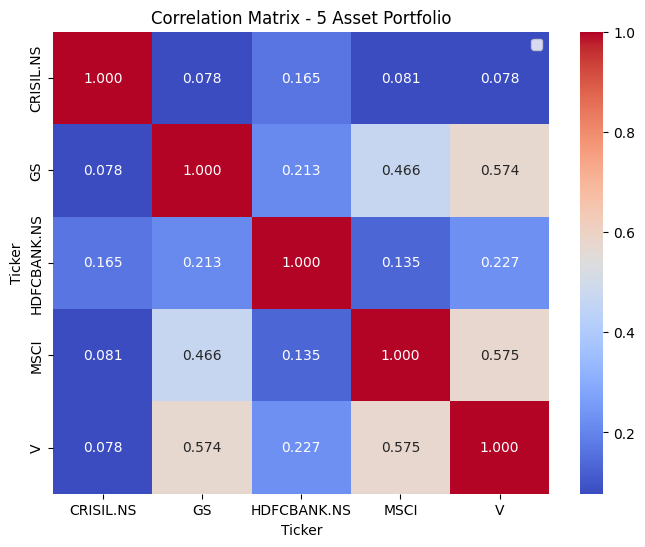

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,fmt="0.3f",cmap='coolwarm')
plt.title("Correlation Matrix - 5 Asset Portfolio")
plt.legend()
plt.show()

**MARKOWITZ OPTIMIZATION**

In [12]:
means_return = returns.mean()
print(f"Mean of daily returns is:\n {means_return}")

Mean of daily returns is:
 Ticker
CRISIL.NS      0.000875
GS             0.001281
HDFCBANK.NS    0.000538
MSCI           0.001089
V              0.000745
dtype: float64


In [14]:
weights = np.array([0.2,0.2,0.2,0.2,0.2]) #starting off with equal weights

In [19]:
portfolio_return = np.dot(weights,means_return)
print(f"The portfolio return is: {round(portfolio_return,4)}")

The portfolio return is: 0.0009


In [21]:
portfolio_variance = np.dot(weights.T,np.dot(cov_matrix,weights))
print(f"The portfolio variance is: {round(portfolio_variance,4)}")

The portfolio variance is: 0.0001


In [22]:
portoflio_standard_deviation = np.sqrt(portfolio_variance)
print(f"The portfolio standard deviation is: {round(portoflio_standard_deviation,4)}")

The portfolio standard deviation is: 0.0122
